# Numerical experiments

This notebook is a thin front-end for the Python modules in this repository.
It reproduces the basic tables/plots used in the paper.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Ensure the repository root is on sys.path (works in VS Code + Jupyter).
ROOT = Path().resolve().parents[0]
if (ROOT / "higherconvexity_experiments.py").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "higherconvexity_experiments.py").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt

from higherconvexity_experiments import (
    default_benchmark_suite,
    run_suite_single_tol,
    run_table_min_intervals_by_tol,
    compare_Qn_vs_Pn,
)
from higherconvexity_rules import peano_kernel_gauss_legendre, peano_kernel_gauss_lobatto


## Certified integration on a small benchmark suite


In [2]:
problems = default_benchmark_suite()
df = run_suite_single_tol(n=4, problems=problems, tol=1e-8, method="uniform_minimal")
df


,problem,interval,n,tol,method,approx,bound,abs_error,bound/abs_error,n_intervals,evals,notes
0,"1/x on [1,2]","(1.0, 2.0)",4,1.000000e-08,uniform_minimal,0.693147,3.838660e-09,2.967725e-09,1.293469,2,17,(2n-1)-convex for all n (since f^{(2n)} > 0).
1,"exp on [0,1]","(0.0, 1.0)",4,1.000000e-08,uniform_minimal,1.718282,5.248889e-10,4.080785e-10,1.286245,1,9,(2n-1)-convex for all n (all derivatives posit...
2,"log(1+x) on [0,1]","(0.0, 1.0)",4,1.000000e-08,uniform_minimal,0.386294,5.994517e-10,4.640285e-10,1.291842,2,17,(2n-1)-concave for all n (even derivatives neg...


## Minimal uniform subdivisions needed to reach a list of tolerances

Example: `f(x)=1/x` on `[1,2]`.


In [3]:
import math

f = lambda x: 1.0 / x
interval = (1.0, 2.0)

# n=2,3,4,5 correspond to (2n-1)=3,5,7,9
n_list = [2, 3, 4, 5]
tol_list = [10.0 ** (-k) for k in range(1, 17)]

tbl = run_table_min_intervals_by_tol(
    f=f,
    interval=interval,
    n_list=n_list,
    tol_list=tol_list,
)
tbl


,tol,N_3,N_5,N_7,N_9
0,1.000000e-01,1,1,1,1
1,1.000000e-02,1,1,1,1
2,1.000000e-03,1,1,1,1
3,1.000000e-04,2,1,1,1
4,1.000000e-05,3,2,1,1
5,1.000000e-06,6,2,1,1
6,1.000000e-07,10,3,2,1
7,1.000000e-08,17,4,2,2
8,1.000000e-09,31,6,3,2
9,1.000000e-10,54,9,4,2


## Single-interval comparison: $Q_n$ versus $P_n$


In [4]:
compare_Qn_vs_Pn(n=4, problems=problems)


,problem,interval,n,|I - Q_n|,|I - P_n|,Q_n approx,P_n approx,exact
0,"1/x on [1,2]","(1.0, 2.0)",4,3.304388e-07,6.086722e-09,0.693147,0.693147,0.693147
1,"exp on [0,1]","(0.0, 1.0)",4,4.080785e-10,1.683098e-13,1.718282,1.718282,1.718282
2,"log(1+x) on [0,1]","(0.0, 1.0)",4,5.893728e-08,8.594693e-10,0.386294,0.386294,0.386294


## Peano kernels: $K_G$ and $K_L$ (example)


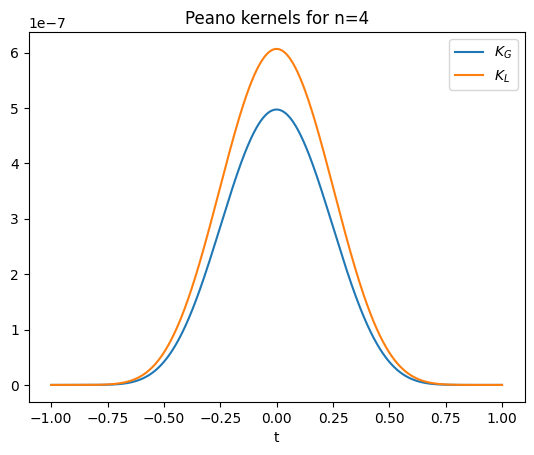

In [5]:
n = 4
t = np.linspace(-1.0, 1.0, 1001)
KG = peano_kernel_gauss_legendre(n, t)
KL = peano_kernel_gauss_lobatto(n, t)

plt.figure()
plt.plot(t, KG, label=r"$K_G$")
plt.plot(t, KL, label=r"$K_L$")
plt.legend()
plt.xlabel("t")
plt.title(f"Peano kernels for n={n}")
plt.show()
